# Natural Language Processing 2

In [1]:
 import pandas as pd

In [2]:
df = pd.read_csv('spam.csv' , encoding = 'iso-8859-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
import seaborn as sns

<Axes: xlabel='v1', ylabel='count'>

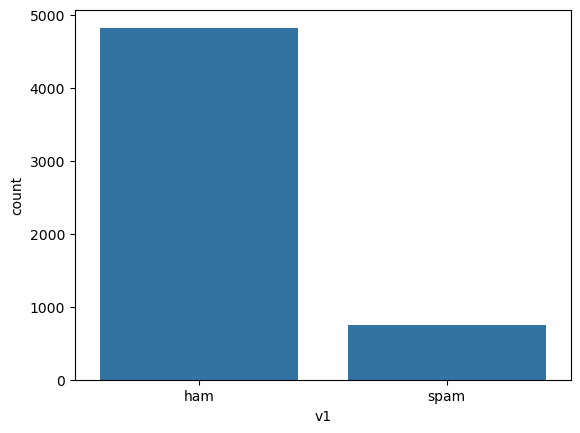

In [5]:
sns.countplot(x = df['v1'])

In [6]:
df['v1'].value_counts()

v1
ham     4825
spam     747
Name: count, dtype: int64

In [7]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'], axis = 1 , inplace = True )

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
df.columns = ['class','text']

In [10]:
df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# pip install neattext

In [12]:
import neattext as nfx

In [13]:
df.head()

,class,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df['text'] = df['text'].apply(nfx.normalize)

In [15]:
df.head()

,class,text
0,ham,"go until jurong point, crazy.. available only ..."
1,ham,ok lar... joking wif u oni...
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor... u c already then say...
4,ham,"nah i don't think he goes to usf, he lives aro..."


In [16]:
df.shape

(5572, 2)

In [17]:
s = ' '.join(df['text']) # tüm sütunlarda ki metinleri tek bir metin yapar.

In [ ]:
s

In [19]:
s = nfx.clean_text(s)

In [20]:
s = nfx.remove_emails(s)

In [21]:
s = nfx.remove_special_characters(s)

In [ ]:
s

In [23]:
s = nfx.TextFrame(s) 

In [24]:
s.describe()

Key      Value          
Length  : 264774         
vowels  : 78171          
consonants: 138955         
stopwords: 2471           
punctuations: 0              
special_char: 0              
tokens(whitespace): 45164          
tokens(words): 45164          


In [25]:
s.length

264774

In [26]:
s.readability() # kitabın kime uygun olduğunu söyler . çocuk mu yetişkin mi ...

{'automated readability': 23829.24233394195, 'description': None}

In [27]:
# Gutenberg kitap kütüphanesini denedik

In [28]:
import nltk

In [29]:
nltk.download('gutenberg')

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [30]:
nltk.corpus.gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

In [31]:
seyhpir = nltk.corpus.gutenberg.raw('shakespeare-hamlet.txt')

In [ ]:
seyhpir

In [33]:
seyhpir = nfx.TextFrame(seyhpir)

In [34]:
seyhpir.readability()

{'automated readability': 12.990613823318782,
 'description': '18-24 years (College student)'}

In [35]:
# Gutenberg kitap kütüphanesini denedik bitti

In [36]:
df['text']=df['text'].str.lower() #kucuk harfe cevir
df['text']=df['text'].str.replace('[^\w\s]','',regex=True) #noktalama isaretlerini kadir
df['text']=df['text'].str.replace('\d+','',regex=True) # rakamlari kaldir
df['text']=df['text'].str.replace('\n','',regex=True) #satir sonlarini kaldir
df['text']=df['text'].str.replace('\r','',regex=True) # enter lari kaldir

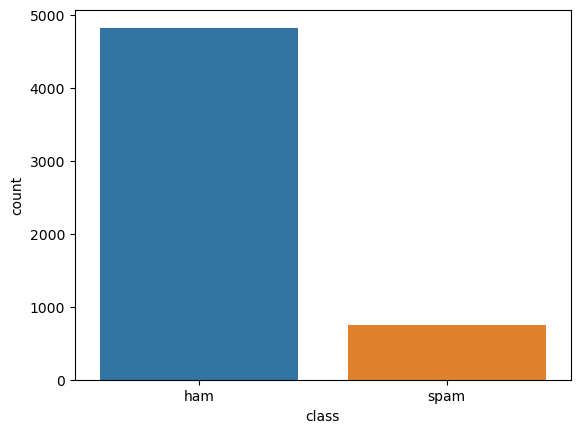

In [37]:
sns.countplot(x=df['class'], hue=df['class']);

In [38]:
# imbalanced Smote Sentetic Data - simulasyon data

In [39]:
x = df['text']
y = df['class']

In [40]:
# poe den alınan sentetic data oluşturma kodu
'''
# Create a sample imbalanced dataset
X, y = make_classification(n_classes=2, class_sep=2,
                           weights=[0.9, 0.1], n_informative=3,
                           n_redundant=1, flip_y=0,
                           n_features=20, n_clusters_per_class=1,
                           n_samples=1000, random_state=42)

print("Original dataset shape:", Counter(y))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Resampled dataset shape:", Counter(y_resampled))
'''

'\n# Create a sample imbalanced dataset\nX, y = make_classification(n_classes=2, class_sep=2,\n                           weights=[0.9, 0.1], n_informative=3,\n                           n_redundant=1, flip_y=0,\n                           n_features=20, n_clusters_per_class=1,\n                           n_samples=1000, random_state=42)\n\nprint("Original dataset shape:", Counter(y))\n\n# Apply SMOTE\nsmote = SMOTE(random_state=42)\nX_resampled, y_resampled = smote.fit_resample(X, y)\n\nprint("Resampled dataset shape:", Counter(y_resampled))\n'

In [41]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [42]:
from sklearn.ensemble import RandomForestClassifier

In [43]:
# pipeline yapilacak işleri sıralı yapar ve boyut problemini çözer

In [44]:
from sklearn.pipeline import Pipeline

In [45]:
clf=Pipeline([('tfidf',TfidfVectorizer()),('Classifier',RandomForestClassifier())])

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
x_train , x_test , y_train, y_test = train_test_split(x, y, random_state= 42 , test_size = 0.2)

In [48]:
clf.fit(x_train , y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('Classifier', RandomForestClassifier())])

In [49]:
tahmin = clf.predict(x_test)

In [50]:
from sklearn.metrics import classification_report,accuracy_score, confusion_matrix

In [51]:
accuracy_score(tahmin , y_test)

0.9721973094170404

In [52]:
print(classification_report(tahmin, y_test))

              precision    recall  f1-score   support

         ham       1.00      0.97      0.98       996
        spam       0.79      1.00      0.88       119

    accuracy                           0.97      1115
   macro avg       0.90      0.98      0.93      1115
weighted avg       0.98      0.97      0.97      1115



In [53]:
confusion_matrix(tahmin , y_test)

array([[965,  31],
       [  0, 119]])

In [54]:
# Support vectore machine

In [55]:
from sklearn.svm import SVC

In [56]:
svm = clf=Pipeline([('tfidf',TfidfVectorizer()),('Classifier',SVC())])

In [57]:
svm.fit(x_train , y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('Classifier', SVC())])

In [58]:
tahmin2 = svm.predict(x_test)

In [59]:
accuracy_score(tahmin2 , y_test)

0.979372197309417

In [60]:
confusion_matrix(tahmin2 , y_test)

array([[965,  23],
       [  0, 127]])

<Axes: >

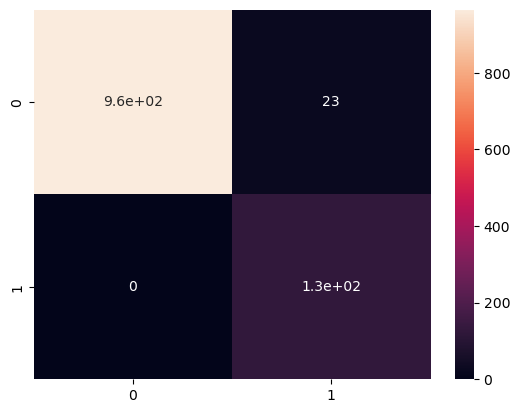

In [61]:
sns.heatmap(confusion_matrix(tahmin2 , y_test) , annot = True)

In [62]:
print(classification_report(tahmin2 , y_test))

              precision    recall  f1-score   support

         ham       1.00      0.98      0.99       988
        spam       0.85      1.00      0.92       127

    accuracy                           0.98      1115
   macro avg       0.92      0.99      0.95      1115
weighted avg       0.98      0.98      0.98      1115



In [63]:
# Test 

In [64]:
test1=['Hello, you are learning Natural Language Processing']
test2=['Congratulations, you won a lottary ticket, to claim call']
test3=['Click here to claim your $1 million']

In [65]:
clf.predict(test1)

array(['ham'], dtype=object)

In [66]:
clf.predict(test2)

array(['spam'], dtype=object)

In [67]:
clf.predict(test3)

array(['spam'], dtype=object)

In [68]:
svm.predict(test1)

array(['ham'], dtype=object)

In [69]:
svm.predict(test2)

array(['spam'], dtype=object)

In [70]:
svm.predict(test3)

array(['spam'], dtype=object)

In [71]:
import joblib

In [72]:
joblib.dump(svm , 'svm_tm_hs.pkl')  # modeli dışarı aktardık

['svm_tm_hs.pkl']

In [73]:
loded_model=joblib.load('svm_tm_hs.pkl') # dışarı aktarılan modeli import edip modele tahmin yaptırdık

In [74]:
loded_model.predict(test2)

array(['spam'], dtype=object)

## Word Cloud

In [75]:
#pip install wordcloud

In [76]:
from wordcloud import WordCloud
from wordcloud import STOPWORDS
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [77]:
def wc(data, color):
    plt.figure(figsize=(10, 10))
    wc = WordCloud(stopwords=STOPWORDS, background_color=color)
    wc.generate(' '.join(data))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.show()


In [78]:
spam = df[df['class'] == 'spam']
ham = df[df['class'] == 'ham']

In [79]:
ham['text']

0       go until jurong point crazy available only in ...
1                                 ok lar joking wif u oni
3             u dun say so early hor u c already then say
4       nah i dont think he goes to usf he lives aroun...
6       even my brother is not like to speak with me t...
                              ...                        
5565                                            huh y lei
5568                 will ì_ b going to esplanade fr home
5569    pity  was in mood for that soany other suggest...
5570    the guy did some bitching but i acted like id ...
5571                            rofl its true to its name
Name: text, Length: 4825, dtype: object

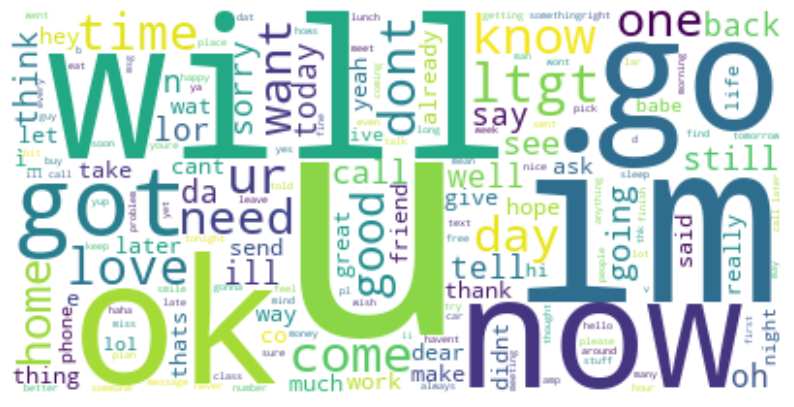

In [80]:
wc(ham['text'] , 'white')

In [81]:
# colud png yi bulamadığım için çalıştırmadım
'''
def wc2(data):
    plt.figure(figsize=(10,10))
    mask=np.array(Image.open('cloud.png'))
    wc=WordCloud(stopwords=STOPWORDS,mask=mask)
    wc.generate(' '.join(data))
    plt.imshow(wc)
'''

"\ndef wc2(data):\n    plt.figure(figsize=(10,10))\n    mask=np.array(Image.open('cloud.png'))\n    wc=WordCloud(stopwords=STOPWORDS,mask=mask)\n    wc.generate(' '.join(data))\n    plt.imshow(wc)\n"

## Sentiment Analysis

In [93]:
df['text'][2]

'free entry in  a wkly comp to win fa cup final tkts  may  text fa to  to receive entry questionstd txt ratetcs apply s'

In [94]:
# sentimet analizde polarity ve subjectivity diye iki olay var // 

In [95]:
# polarity -1 0 1 değerlerini alır. - 1 extreme negative , o nötr , 1 extreme positive ,

In [96]:
#  subjectivity : 0,1 arasında değer alır

In [97]:
text = 'I love programming and AI'

In [98]:
from textblob import TextBlob

In [99]:
blob = TextBlob(text)

In [100]:
blob.sentiment

Sentiment(polarity=0.5, subjectivity=0.6)

In [104]:
text2 = 'I hate programming and AI'

In [105]:
blob = TextBlob(text2)

In [106]:
blob.sentiment

Sentiment(polarity=-0.8, subjectivity=0.9)